<h1 style="text-align:center;"><b>Proyecto 1</b></h1>
<h3 style="text-align:center;">Marcos Díaz (221102), Daniel Machic (22118), Maria Jose Ramírez (221051)</h3>

**GitHub**: https://github.com/mac2218/IA-Proyecto2.git

## Librerías

In [ ]:
import numpy as np
import random
import time
import heapq
from collections import deque
import matplotlib.pyplot as plt

## 1. Generación aleatoria de laberintos

Se implementan dos algoritmos para generar laberintos basados en árboles de expansión mínima:

### Algoritmo de Prim
Construye el laberinto expandiendo desde una celda inicial, agregando vecinos aleatorios y asegurando conectividad sin ciclos.

### Algoritmo de Kruskal
Construye el laberinto considerando todas las paredes como posibles conexiones y eliminándolas si conectan componentes diferentes (usando Union-Find).

Ambos algoritmos garantizan:
- Conectividad total
- Ausencia de ciclos
- Existencia de un único camino entre dos puntos

In [ ]:
# Direcciones (movimientos de 2 celdas para evitar ciclos)
DIRS = [(2,0), (-2,0), (0,2), (0,-2)]

def in_bounds(r, c, rows, cols):
    return 0 <= r < rows and 0 <= c < cols

### Prim

In [ ]:
def prim_maze(rows, cols):
    maze = [[0]*cols for _ in range(rows)]

    # punto inicial (solo en posiciones pares)
    start = (random.randrange(0, rows, 2), random.randrange(0, cols, 2))
    maze[start[0]][start[1]] = 1

    walls = []

    def add_walls(r, c):
        for dr, dc in DIRS:
            nr, nc = r+dr, c+dc
            if in_bounds(nr, nc, rows, cols) and maze[nr][nc] == 0:
                walls.append((r, c, nr, nc))

    add_walls(*start)

    while walls:
        r, c, nr, nc = random.choice(walls)
        walls.remove((r, c, nr, nc))

        if maze[nr][nc] == 0:
            maze[nr][nc] = 1
            maze[(r+nr)//2][(c+nc)//2] = 1
            add_walls(nr, nc)

    return maze

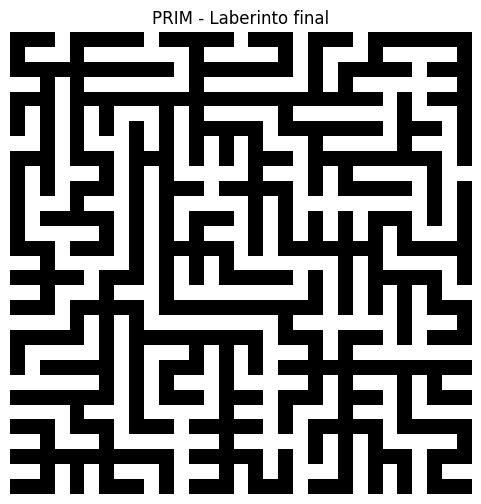

In [26]:
from IPython.display import clear_output

DIRS = [(2,0), (-2,0), (0,2), (0,-2)]

def in_bounds(r, c, rows, cols):
    return 0 <= r < rows and 0 <= c < cols


def animate_prim_simple(rows, cols, delay=0.05, step=5):
    maze = [[0]*cols for _ in range(rows)]
    maze[0][0] = 1

    walls = [(0,0,2,0),(0,0,0,2)]

    i = 0
    while walls:
        i += 1

        r, c, nr, nc = random.choice(walls)
        walls.remove((r, c, nr, nc))

        if in_bounds(nr, nc, rows, cols) and maze[nr][nc] == 0:
            maze[nr][nc] = 1
            maze[(r+nr)//2][(c+nc)//2] = 1

            for dr, dc in DIRS:
                walls.append((nr, nc, nr+dr, nc+dc))

        # Mostrar solo cada cierto número de pasos (evita spam)
        if i % step == 0:
            clear_output(wait=True)
            plt.figure(figsize=(6,6))
            plt.imshow(maze, cmap="binary")
            plt.title("Construcción del laberinto (Prim)")
            plt.axis("off")
            plt.show()
            time.sleep(delay)

    # mostrar resultado final
    clear_output(wait=True)
    plt.figure(figsize=(6,6))
    plt.imshow(maze, cmap="binary")
    plt.title("PRIM - Laberinto final")
    plt.axis("off")
    plt.show()

animate_prim_simple(31, 31)

Se implementó el algoritmo de Prim de manera aleatoria, donde el laberinto se construye expandiendo progresivamente un conjunto de celdas conectadas mediante la selección aleatoria de fronteras, garantizando así un árbol generador sin ciclos

### KRUSKAL 

In [ ]:
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        rootA = self.find(a)
        rootB = self.find(b)
        if rootA != rootB:
            self.parent[rootB] = rootA

def kruskal_maze(rows, cols):
    maze = [[0]*cols for _ in range(rows)]
    uf = UnionFind()

    cells = []

    # Inicializar celdas (solo pares)
    for r in range(0, rows, 2):
        for c in range(0, cols, 2):
            maze[r][c] = 1
            uf.parent[(r, c)] = (r, c)
            cells.append((r, c))

    edges = []

    # Crear posibles conexiones
    for r, c in cells:
        for dr, dc in DIRS:
            nr, nc = r+dr, c+dc
            if in_bounds(nr, nc, rows, cols):
                edges.append((r, c, nr, nc))

    random.shuffle(edges)

    for r, c, nr, nc in edges:
        if uf.find((r, c)) != uf.find((nr, nc)):
            uf.union((r, c), (nr, nc))

            # romper pared
            maze[(r+nr)//2][(c+nc)//2] = 1
            maze[nr][nc] = 1

    return maze

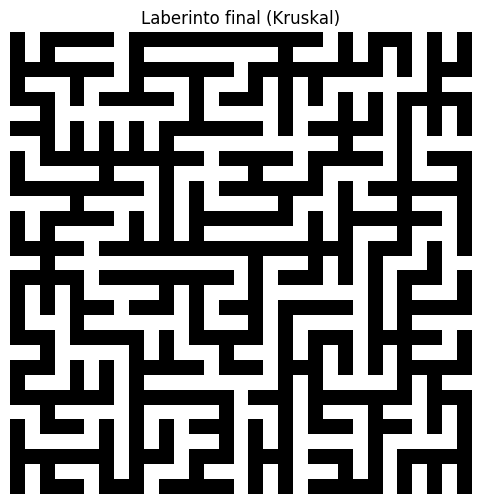

In [ ]:
from IPython.display import clear_output

DIRS = [(2,0), (-2,0), (0,2), (0,-2)]

def in_bounds(r, c, rows, cols):
    return 0 <= r < rows and 0 <= c < cols


# -------- UNION FIND --------
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        rootA = self.find(a)
        rootB = self.find(b)
        if rootA != rootB:
            self.parent[rootB] = rootA


# -------- ANIMACIÓN KRUSKAL --------
def animate_kruskal(rows, cols, delay=0.05, step=5):
    maze = [[0]*cols for _ in range(rows)]
    uf = UnionFind()

    cells = []

    # Inicializar celdas (nodos)
    for r in range(0, rows, 2):
        for c in range(0, cols, 2):
            maze[r][c] = 1
            uf.parent[(r,c)] = (r,c)
            cells.append((r,c))

    edges = []

    # Generar posibles conexiones
    for r, c in cells:
        for dr, dc in DIRS:
            nr, nc = r+dr, c+dc
            if in_bounds(nr, nc, rows, cols):
                edges.append((r, c, nr, nc))

    random.shuffle(edges)

    i = 0
    for r, c, nr, nc in edges:
        i += 1

        if uf.find((r,c)) != uf.find((nr,nc)):
            uf.union((r,c), (nr,nc))

            # romper pared
            maze[(r+nr)//2][(c+nc)//2] = 1
            maze[nr][nc] = 1

        # animación controlada
        if i % step == 0:
            clear_output(wait=True)
            plt.figure(figsize=(6,6))
            plt.imshow(maze, cmap="binary")
            plt.title("Construcción del laberinto (Kruskal)")
            plt.axis("off")
            plt.show()
            time.sleep(delay)

    # mostrar resultado final
    clear_output(wait=True)
    plt.figure(figsize=(6,6))
    plt.imshow(maze, cmap="binary")
    plt.title("Laberinto final (Kruskal)")
    plt.axis("off")
    plt.show()

animate_kruskal(31, 31)

A diferencia del algoritmo de Prim, Kruskal no expande desde un nodo inicial, sino que considera todas las posibles conexiones entre celdas y elimina paredes únicamente cuando conectan componentes disjuntos, utilizando una estructura Union-Find para evitar ciclos.

## 2. Solución de un laberinto aleatorio


Se busca encontrar la ruta más corta en un laberinto de tamaño 60x80 desde:
- Inicio: (1,1)

- Meta: (60,80)

Se implementan algoritmos de búsqueda para:

- Encontrar el camino óptimo

- Medir nodos explorados

- Visualizar la solución